In [1]:
from ultralytics import YOLO, RTDETR
import cv2
import os
import time
import torch
import pandas as pd
from pathlib import Path
from tqdm import tqdm

In [2]:
from ultralytics import YOLO, RTDETR

import cv2
import torch
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

In [3]:
# pip install pandas

In [4]:
VAL_ROOT = Path(
    r"C:\Users\VAMSEEKRISHNA.P\Desktop\assignment\VisDrone2019-MOT-val\VisDrone2019-MOT-val"
)


SEQ_DIR = VAL_ROOT / "sequences"

ANN_DIR = VAL_ROOT / "annotations"



all_images=[]


for seq in sorted(SEQ_DIR.iterdir()):

    imgs = sorted(
        seq.glob("*.jpg")
    )

    all_images.extend(imgs)


print(
    "Total validation frames:",
    len(all_images)
)

Total validation frames: 2846


In [5]:
# def load_gt(annotation_file):

#     gt_boxes = defaultdict(list)


#     with open(annotation_file,"r") as f:


#         for line in f:

#             data=line.strip().split(",")


#             frame=int(data[0])

#             x=float(data[2])
#             y=float(data[3])

#             w=float(data[4])
#             h=float(data[5])


#             cls=int(data[7])


#             if cls in [1,2]:

#                 gt_boxes[frame].append(
#                     [
#                         x,
#                         y,
#                         x+w,
#                         y+h
#                     ]
#                 )


#     return gt_boxes



# gt_boxes = load_gt(annotation_file)


# avg_gt = (
#     sum(len(v) for v in gt_boxes.values())
#     /
#     len(gt_boxes)
# )


# print("GT/frame:",avg_gt)

In [6]:
def iou(box1,box2):

    x1=max(box1[0],box2[0])
    y1=max(box1[1],box2[1])

    x2=min(box1[2],box2[2])
    y2=min(box1[3],box2[3])


    inter=max(0,x2-x1)*max(0,y2-y1)


    area1=(box1[2]-box1[0])*(box1[3]-box1[1])

    area2=(box2[2]-box2[0])*(box2[3]-box2[1])


    union=area1+area2-inter


    return inter/union if union>0 else 0

In [7]:
def evaluate(
    model,
    imgsz
):

    TP=0
    FP=0
    FN=0


    total_det=0
    total_time=0


    # for AP calculation

    confidences=[]
    matches=[]


    # warmup

    img=cv2.imread(str(images[0]))


    for _ in range(5):

        model(
            img,
            imgsz=imgsz,
            classes=[0],
            device=0,
            verbose=False
        )


    torch.cuda.synchronize()



    for idx,img_path in enumerate(tqdm(images)):


        frame_id=idx+1


        img=cv2.imread(str(img_path))


        start=torch.cuda.Event(
            enable_timing=True
        )

        end=torch.cuda.Event(
            enable_timing=True
        )


        start.record()


        result=model(
            img,
            imgsz=imgsz,
            conf=0.20,
            classes=[0],
            device=0,
            verbose=False
        )[0]


        end.record()

        torch.cuda.synchronize()


        total_time += (
            start.elapsed_time(end)
        )


        preds=result.boxes.xyxy.cpu().numpy()

        confs=result.boxes.conf.cpu().numpy()


        total_det += len(preds)



        gt=gt_boxes[frame_id]

        used=set()


        for pred,conf in zip(preds,confs):


            best=0
            best_id=-1


            for i,g in enumerate(gt):

                if i in used:
                    continue


                score=iou(pred,g)


                if score>best:

                    best=score
                    best_id=i



            confidences.append(conf)


            if best>=0.5:

                TP+=1

                used.add(best_id)

                matches.append(1)


            else:

                FP+=1

                matches.append(0)



        FN += len(gt)-len(used)



    precision = (
        TP/(TP+FP)
        if TP+FP else 0
    )


    recall = (
        TP/(TP+FN)
        if TP+FN else 0
    )


    fps = (
        len(images)
        /
        (total_time/1000)
    )


    avg_det = (
        total_det/
        len(images)
    )


    # mAP50 calculation

    if len(matches)>0:

        order=np.argsort(
            -np.array(confidences)
        )

        sorted_matches=np.array(matches)[order]


        tp=np.cumsum(sorted_matches)

        fp=np.cumsum(
            1-sorted_matches
        )


        recalls=tp/(TP+FN+1e-6)

        precisions=tp/(tp+fp+1e-6)


        map50=np.trapz(
            precisions,
            recalls
        )


    else:

        map50=0



    return {

        "det":
        avg_det,

        "fps":
        fps,

        "precision":
        precision,

        "recall":
        recall,

        "map50":
        map50
    }

In [8]:
# images=sorted(
#     list(Path(sequence_path).glob("*.jpg"))
# )


# images=images[:300]

# print(len(images))

In [9]:
# models={

# "YOLOv8s":
# YOLO("yolov8s.pt"),

# "yolov8m":
# YOLO("yolov8m.pt"), 

# "yolov8l":
# YOLO("yolov8l.pt"),


# "YOLO11s":
# YOLO("yolo11s.pt"),


# "YOLO11m":
# YOLO("yolo11m.pt"),


# "YOLO11l":
# YOLO("yolo11l.pt"),


# "RTDETR-R18":
# RTDETR("rtdetr-l.pt")   # replace if using r18 weights

# }


# for m in models.values():
#     m.to("cuda")

In [10]:
# resolutions=[640,800,960,1120,1280]


# final=[]


# for name,model in models.items():


#     for res in resolutions:


#         print(
#             "\nTesting:",
#             name,
#             res
#         )


#         r=evaluate(
#             model,
#             res
#         )


#         final.append({

#             "Model":name,

#             "Resolution":res,

#             "Avg Persons Detected":
#             round(r["det"],2),


#             "GT Persons/frame":
#             round(avg_gt,2),


#             "FPS":
#             round(r["fps"],2),


#             "Precision":
#             round(r["precision"],3),


#             "Recall":
#             round(r["recall"],3),


#             "mAP50":
#             round(r["map50"],3)

#         })



# df=pd.DataFrame(final)

# df

In [31]:
#####

In [11]:
def load_all_gt():


    database={}


    for ann in ANN_DIR.glob("*.txt"):


        seq_name = ann.stem


        database[seq_name] = defaultdict(list)



        with open(ann,"r") as f:


            for line in f:


                d=line.strip().split(",")


                frame=int(d[0])


                cls=int(d[7])


                if cls in [1,2]:


                    x=float(d[2])
                    y=float(d[3])
                    w=float(d[4])
                    h=float(d[5])


                    database[seq_name][frame].append(
                        [
                            x,
                            y,
                            x+w,
                            y+h
                        ]
                    )


    return database



gt_database = load_all_gt()



total_gt=sum(
    len(v)
    for seq in gt_database.values()
    for v in seq.values()
)


avg_gt = total_gt / len(all_images)


print(
    "Average GT persons/frame:",
    avg_gt
)

Average GT persons/frame: 17.67814476458187


In [12]:
def box_iou(a,b):


    x1=max(a[0],b[0])
    y1=max(a[1],b[1])

    x2=min(a[2],b[2])
    y2=min(a[3],b[3])


    inter=max(0,x2-x1)*max(0,y2-y1)



    area1=(a[2]-a[0])*(a[3]-a[1])

    area2=(b[2]-b[0])*(b[3]-b[1])


    union=area1+area2-inter


    if union==0:
        return 0


    return inter/union

In [13]:
def compute_ap(
    predictions,
    total_gt,
    threshold
):


    predictions=sorted(
        predictions,
        key=lambda x:x[0],
        reverse=True
    )


    tp=[]
    fp=[]


    for conf,iou in predictions:


        if iou>=threshold:

            tp.append(1)
            fp.append(0)

        else:

            tp.append(0)
            fp.append(1)



    tp=np.cumsum(tp)

    fp=np.cumsum(fp)



    recall=tp/(total_gt+1e-6)

    precision=tp/(tp+fp+1e-6)



    ap=np.trapz(
        precision,
        recall
    )


    return ap

In [14]:
def evaluate_model(
    model,
    imgsz
):


    TP=0
    FP=0
    FN=0


    detections=0


    predictions_for_map=[]


    pre_time=0
    infer_time=0
    post_time=0



    # warmup

    img=cv2.imread(str(all_images[0]))

    for _ in range(5):

        model(
            img,
            imgsz=imgsz,
            classes=[0],
            device=0,
            verbose=False
        )


    torch.cuda.synchronize()



    for img_path in tqdm(all_images):


        seq=img_path.parent.name


        frame=int(
            img_path.stem
        )


        img=cv2.imread(str(img_path))



        result=model(
            img,
            imgsz=imgsz,
            conf=0.20,
            classes=[0],
            device=0,
            verbose=False
        )[0]



        torch.cuda.synchronize()



        pre_time += result.speed["preprocess"]

        infer_time += result.speed["inference"]

        post_time += result.speed["postprocess"]



        pred_boxes=result.boxes.xyxy.cpu().numpy()

        confs=result.boxes.conf.cpu().numpy()


        detections += len(pred_boxes)



        gt_boxes=gt_database[seq][frame]


        matched=set()



        for box,conf in zip(pred_boxes,confs):


            best_iou=0
            best_gt=-1



            for i,g in enumerate(gt_boxes):


                if i in matched:

                    continue


                score=box_iou(
                    box,g
                )


                if score>best_iou:

                    best_iou=score
                    best_gt=i




            predictions_for_map.append(
                [
                    conf,
                    best_iou
                ]
            )



            if best_iou>=0.5:


                TP+=1

                matched.add(best_gt)


            else:

                FP+=1



        FN += (
            len(gt_boxes)
            -
            len(matched)
        )



    n=len(all_images)



    precision=TP/(TP+FP+1e-6)

    recall=TP/(TP+FN+1e-6)



    map50 = compute_ap(
        predictions_for_map,
        total_gt,
        0.5
    )


    maps=[]


    for t in np.arange(
        0.5,
        1.0,
        0.05
    ):


        maps.append(
            compute_ap(
                predictions_for_map,
                total_gt,
                t
            )
        )


    map5095=np.mean(maps)



    latency=(

        pre_time+
        infer_time+
        post_time

    )/n


    fps=1000/latency



    return {


        "det":
        detections/n,


        "precision":
        precision,


        "recall":
        recall,


        "map50":
        map50,


        "map5095":
        map5095,


        "fps":
        fps,


        "pre":
        pre_time/n,


        "infer":
        infer_time/n,


        "post":
        post_time/n

    }

In [15]:
models={

"YOLOv8s":
YOLO("yolov8s.pt"),

"yolov8m":
YOLO("yolov8m.pt"), 

"yolov8l":
YOLO("yolov8l.pt"),


"YOLO11s":
YOLO("yolo11s.pt"),


"YOLO11m":
YOLO("yolo11m.pt"),


"YOLO11l":
YOLO("yolo11l.pt"),


"RTDETR-R18":
RTDETR("rtdetr-l.pt")   # replace if using r18 weights

}


for m in models.values():
    m.to("cuda")

In [16]:
experiments=[]


resolutions=[

640,
960,
1120,
1280

]


for name,model in models.items():


    for res in resolutions:


        print(
            "\nTesting",
            name,
            res
        )



        r=evaluate_model(
            model,
            res
        )



        experiments.append(
        {

        "Model":
        name,


        "Resolution":
        res,


        "Avg Persons Detected":
        round(r["det"],2),


        "GT Persons/frame":
        round(avg_gt,2),


        "FPS":
        round(r["fps"],2),


        "Precision":
        round(r["precision"],3),


        "Recall":
        round(r["recall"],3),


        "mAP50":
        round(r["map50"],3),


        "mAP50-95":
        round(r["map5095"],3),


        "Inference(ms)":
        round(r["infer"],2)


        }
        )



df=pd.DataFrame(
    experiments
)


df.to_csv("model_resolution_benchmark.csv",index=False)
df


Testing YOLOv8s 640


100%|██████████| 2846/2846 [01:13<00:00, 38.79it/s]
C:\Users\VAMSEEKRISHNA.P\AppData\Local\Temp\ipykernel_12392\1739823922.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap=np.trapz(



Testing YOLOv8s 960


100%|██████████| 2846/2846 [01:24<00:00, 33.85it/s]



Testing YOLOv8s 1120


...


Testing RTDETR-R18 1120


100%|██████████| 2846/2846 [04:06<00:00, 11.55it/s]



Testing RTDETR-R18 1280


100%|██████████| 2846/2846 [05:04<00:00,  9.34it/s]


,Model,Resolution,Avg Persons Detected,GT Persons/frame,FPS,Precision,Recall,mAP50,mAP50-95,Inference(ms)
0,YOLOv8s,640,9.17,17.68,86.87,0.702,0.365,0.320,0.126,8.74
1,YOLOv8s,960,12.73,17.68,65.29,0.678,0.488,0.423,0.171,10.54
2,YOLOv8s,1120,14.39,17.68,57.88,0.654,0.532,0.458,0.184,11.77
3,YOLOv8s,1280,15.81,17.68,49.67,0.627,0.560,0.478,0.191,13.50
4,yolov8m,640,9.96,17.68,70.64,0.722,0.407,0.353,0.147,11.55
5,yolov8m,960,13.88,17.68,45.43,0.670,0.526,0.449,0.184,17.39
6,yolov8m,1120,15.06,17.68,35.01,0.654,0.557,0.475,0.194,23.09
7,yolov8m,1280,16.09,17.68,25.95,0.637,0.580,0.492,0.201,31.91
8,yolov8l,640,9.28,17.68,57.41,0.746,0.391,0.347,0.150,14.85
9,yolov8l,960,12.16,17.68,31.17,0.718,0.494,0.433,0.184,27.44


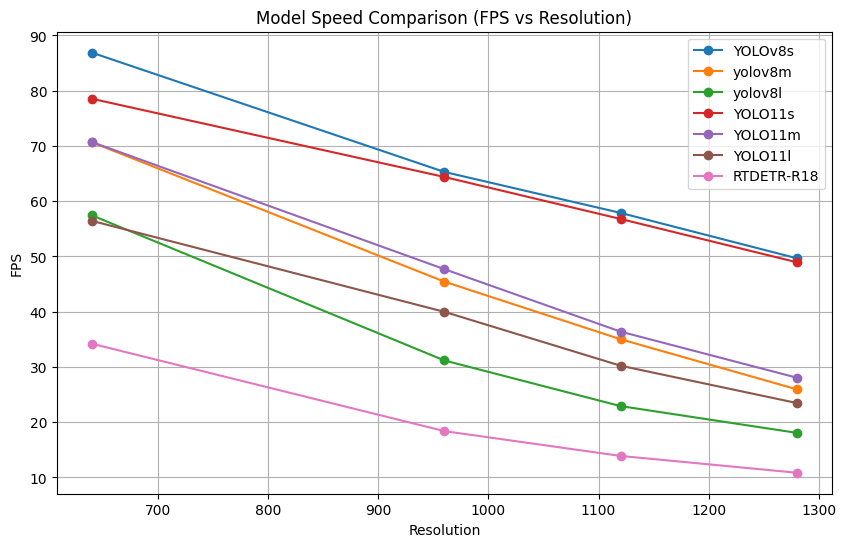

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model in df["Model"].unique():
    temp = df[df["Model"] == model]
    plt.plot(temp["Resolution"], temp["FPS"], marker='o', label=model)

plt.xlabel("Resolution")
plt.ylabel("FPS")
plt.title("Model Speed Comparison (FPS vs Resolution)")
plt.grid(True)
plt.legend()
plt.show()

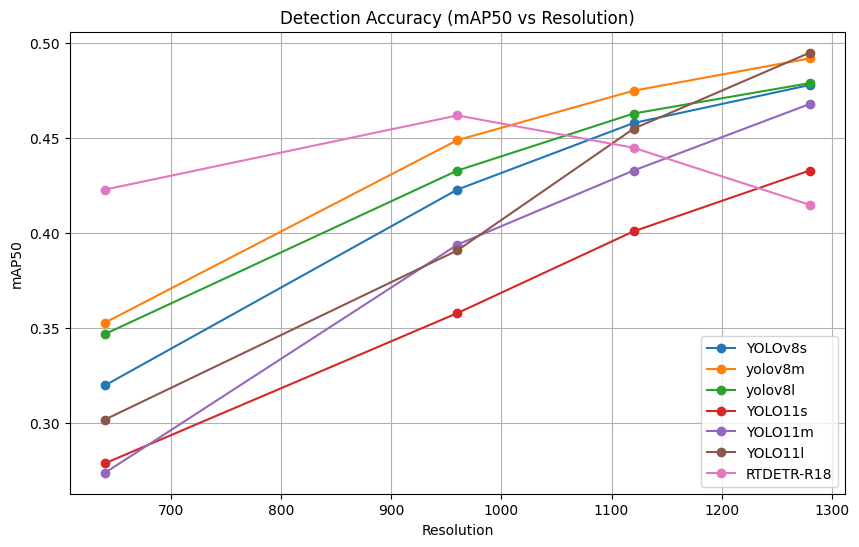

In [18]:
plt.figure(figsize=(10,6))

for model in df["Model"].unique():
    temp = df[df["Model"] == model]
    plt.plot(temp["Resolution"], temp["mAP50"], marker='o', label=model)

plt.xlabel("Resolution")
plt.ylabel("mAP50")
plt.title("Detection Accuracy (mAP50 vs Resolution)")
plt.grid(True)
plt.legend()
plt.show()

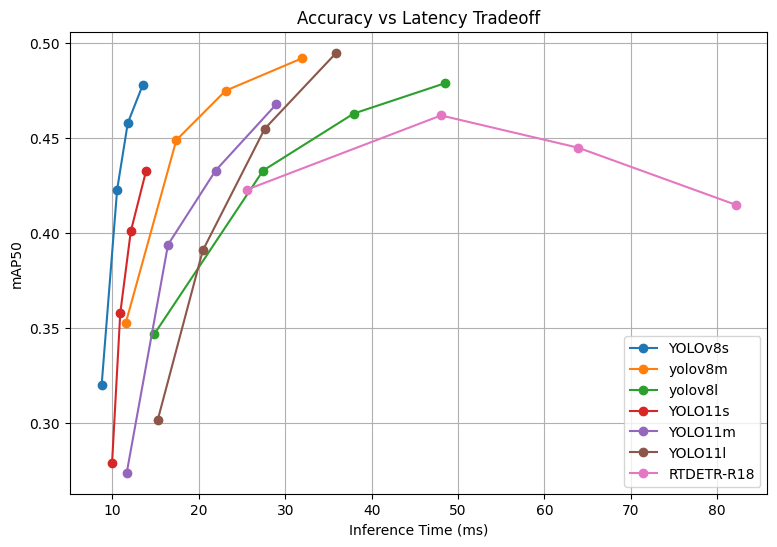

In [19]:
plt.figure(figsize=(9,6))

for model in df["Model"].unique():
    temp=df[df["Model"]==model]

    plt.plot(
        temp["Inference(ms)"],
        temp["mAP50"],
        marker='o',
        label=model
    )

plt.xlabel("Inference Time (ms)")
plt.ylabel("mAP50")
plt.title("Accuracy vs Latency Tradeoff")
plt.grid(True)
plt.legend()
plt.show()

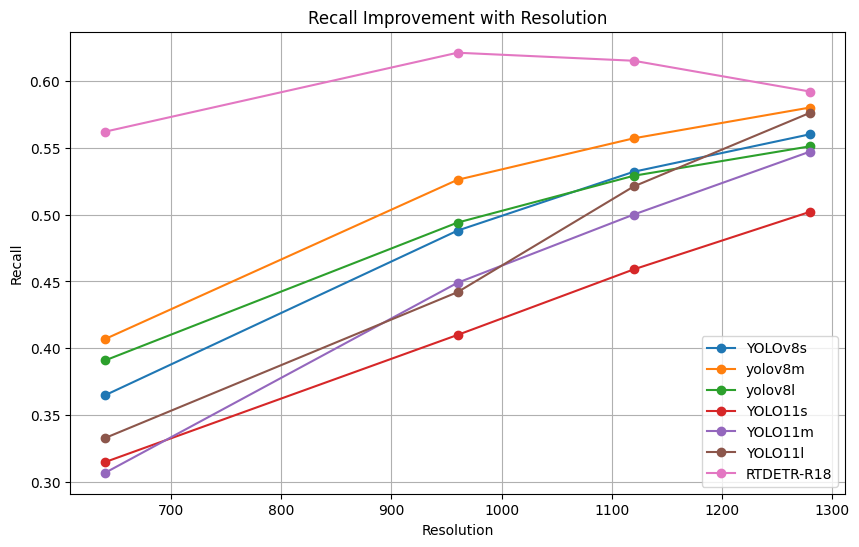

In [20]:
plt.figure(figsize=(10,6))

for model in df["Model"].unique():
    temp=df[df["Model"]==model]
    plt.plot(
        temp["Resolution"],
        temp["Recall"],
        marker='o',
        label=model
    )

plt.xlabel("Resolution")
plt.ylabel("Recall")
plt.title("Recall Improvement with Resolution")
plt.grid(True)
plt.legend()
plt.show()

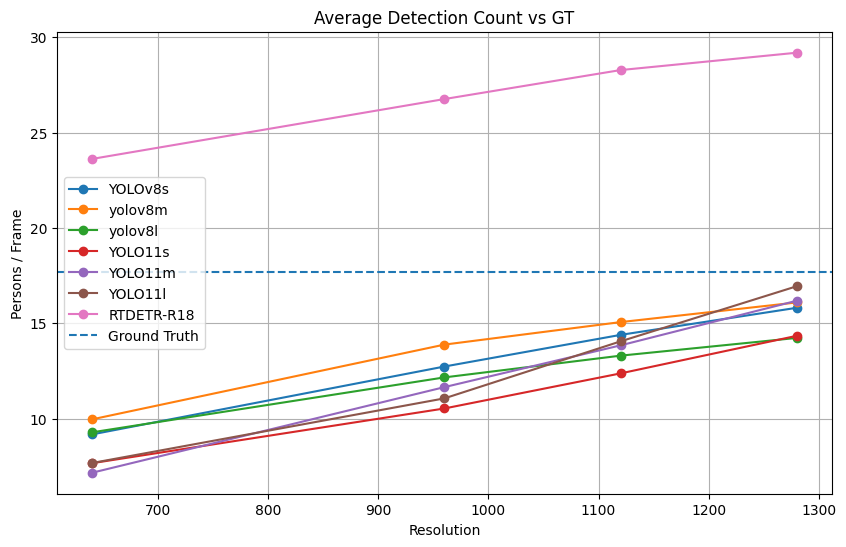

In [21]:
plt.figure(figsize=(10,6))

for model in df["Model"].unique():
    temp=df[df["Model"]==model]
    plt.plot(
        temp["Resolution"],
        temp["Avg Persons Detected"],
        marker='o',
        label=model
    )

plt.axhline(
    df["GT Persons/frame"].iloc[0],
    linestyle="--",
    label="Ground Truth"
)

plt.xlabel("Resolution")
plt.ylabel("Persons / Frame")
plt.title("Average Detection Count vs GT")
plt.grid(True)
plt.legend()
plt.show()